# Notebook 05 — LSTM-Autoencoder

**TFG:** Detección de Anomalías de Consumo Eléctrico y Mitigación de Ataques FDI en Edge Computing

---

### Mejoras v3 (lecciones NB03/NB04 + fix escalado)

| Lección | Aplicación |
|---|---|
| BatchNorm contraproducente (NB04) | **Sin BatchNorm** |
| RobustScaler con IQR≈0 genera valores enormes → LSTM no converge (v2: val_loss=24) | **RobustScaler + clip [-5,5]** |
| MSE uniforme diluye señal (NB04 v3) | **MSE ponderado** por feature |
| mode='base' (8 feat) pierde vi_res_abs | **mode='medium' + vi_res_abs** (14 features) |
| Temporal voting mejora precision | **Temporal voting** sobre timesteps expandidos |

## 0. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, RepeatVector, TimeDistributed
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, fbeta_score,
    precision_score, recall_score,
    average_precision_score, precision_recall_curve
)
import joblib, time, os, json, warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

print(f'TensorFlow {tf.__version__}')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'Metal GPU: {gpus[0].name}')
    BATCH_SIZE = 512
else:
    tf.config.threading.set_intra_op_parallelism_threads(0)
    tf.config.threading.set_inter_op_parallelism_threads(0)
    BATCH_SIZE = 256
    print('CPU mode')

print(f'Batch: {BATCH_SIZE} | Precision: float32')
print('OK')

TensorFlow 2.16.2
Metal GPU: /physical_device:GPU:0
Batch: 512 | Precision: float32
OK


## 1. Carga de Datos Reales

In [3]:
BASE_DIR = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/'
DATA_DIR = os.path.join(BASE_DIR, 'data')

with open(os.path.join(DATA_DIR, 'pipeline_config.json')) as f:
    config = json.load(f)

FEATURE_COLS = config['feature_cols']
ATTACK_TYPES = config['attack_types']

df_train = pd.read_csv(os.path.join(DATA_DIR, 'train_clean.csv'),
                        index_col='datetime', parse_dates=True)
df_val   = pd.read_csv(os.path.join(DATA_DIR, 'val_with_attacks.csv'),
                        index_col='datetime', parse_dates=True)
df_test  = pd.read_csv(os.path.join(DATA_DIR, 'test_with_attacks.csv'),
                        index_col='datetime', parse_dates=True)

print('DATOS CARGADOS (reales UCI)')
print('=' * 65)
for nm, d in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    n_atk = (d['label'] == 1).sum() if 'label' in d.columns else 0
    rng = f'{d.index.min().date()} -> {d.index.max().date()}'
    atk = f'  | {n_atk:,} ataques ({n_atk/len(d)*100:.1f}%)' if n_atk else ''
    print(f'  {nm:6s} {len(d):>10,} filas  {rng}{atk}')

DATOS CARGADOS (reales UCI)
  Train   1,300,061 filas  2006-12-16 -> 2009-06-09
  Val       144,452 filas  2009-06-09 -> 2009-09-20  | 7,207 ataques (5.0%)
  Test      604,999 filas  2009-09-20 -> 2010-11-26  | 31,272 ataques (5.2%)


## 2. Features y Escalado (mode = `medium` + vi_res_abs, 14 features)

**RobustScaler + clip [-5, 5]**: RobustScaler usa mediana/IQR, robusto a outliers.
Pero features como Sub_metering_1/2 tienen mediana=0, IQR≈0 → al dividir por IQR≈0,
genera valores escalados de ±5000. El LSTM con tanh no puede reconstruir esos rangos
→ val_loss=24 en v2 (vs 0.015 del Dense-AE). El clip limita a [-5,5] post-escalado,
preservando la robustez sin generar extremos irreconstruibles.

In [4]:
def compute_features(df, mode='full'):
    '''Identical to NB02/NB03/NB04.'''
    f = df[FEATURE_COLS].copy()
    f['VI_residual'] = (
        df['Global_active_power']
        - df['Voltage'] * df['Global_intensity'] / 1000.0
    )
    if mode in ('medium', 'full'):
        h = df.index.hour + df.index.minute / 60.0
        f['hour_sin'] = np.sin(2 * np.pi * h / 24)
        f['hour_cos'] = np.cos(2 * np.pi * h / 24)
        d = df.index.dayofweek
        f['dow_sin'] = np.sin(2 * np.pi * d / 7)
        f['dow_cos'] = np.cos(2 * np.pi * d / 7)
        f['gap_diff1'] = df['Global_active_power'].diff().fillna(0)
    if mode == 'full':
        f['vi_res_abs'] = f['VI_residual'].abs()
        f['vi_res_roll15_mean'] = f['vi_res_abs'].rolling(15, min_periods=1).mean()
        f['gap_intensity_ratio'] = (
            df['Global_active_power'] / (df['Global_intensity'] + 0.01)
        )
        sm_sum = df['Sub_metering_1'] + df['Sub_metering_2'] + df['Sub_metering_3']
        gap_wh = df['Global_active_power'] * 1000 / 60 + 1e-8
        f['sm_gap_ratio'] = np.clip(sm_sum / gap_wh, 0, 3)
    return f

X_train_df = compute_features(df_train, mode='medium')
X_val_df   = compute_features(df_val,   mode='medium')
X_test_df  = compute_features(df_test,  mode='medium')

X_train_df['vi_res_abs'] = X_train_df['VI_residual'].abs()
X_val_df['vi_res_abs']   = X_val_df['VI_residual'].abs()
X_test_df['vi_res_abs']  = X_test_df['VI_residual'].abs()

feat_names = list(X_train_df.columns)
n_features = len(feat_names)

# ── RobustScaler + CLIP [-5, 5] ──
# RobustScaler con features de IQR≈0 (Sub_metering_1/2 son mayormente 0)
# genera valores ±5000. El clip limita el rango sin perder robustez.
CLIP_RANGE = 5.0
scaler = RobustScaler()
X_train_scaled = np.clip(scaler.fit_transform(X_train_df.values), -CLIP_RANGE, CLIP_RANGE)
X_val_scaled   = np.clip(scaler.transform(X_val_df.values), -CLIP_RANGE, CLIP_RANGE)
X_test_scaled  = np.clip(scaler.transform(X_test_df.values), -CLIP_RANGE, CLIP_RANGE)

X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0).astype(np.float32)
X_val_scaled   = np.nan_to_num(X_val_scaled, nan=0.0).astype(np.float32)
X_test_scaled  = np.nan_to_num(X_test_scaled, nan=0.0).astype(np.float32)

y_val  = df_val['label'].values
y_test = df_test['label'].values

print(f'Features ({n_features}): {feat_names}')
print(f'Scaler: RobustScaler + clip [{-CLIP_RANGE}, {CLIP_RANGE}]')
print(f'Escalado: {X_train_scaled.shape} / {X_val_scaled.shape} / {X_test_scaled.shape}')
print()
print('Rango por feature tras escalado+clip:')
for j, fn in enumerate(feat_names):
    col = X_train_scaled[:, j]
    print(f'  {fn:30s}  [{col.min():.2f}, {col.max():.2f}]  mean={col.mean():.3f}')

Features (14): ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'VI_residual', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'gap_diff1', 'vi_res_abs']
Scaler: RobustScaler + clip [-5.0, 5.0]
Escalado: (1300061, 14) / (144452, 14) / (604999, 14)

Rango por feature tras escalado+clip:
  Global_active_power             [-0.42, 5.00]  mean=0.419
  Global_reactive_power           [-0.53, 5.00]  mean=0.111
  Voltage                         [-4.13, 3.18]  mean=-0.045
  Global_intensity                [-0.46, 5.00]  mean=0.417
  Sub_metering_1                  [0.00, 5.00]  mean=0.225
  Sub_metering_2                  [0.00, 5.00]  mean=0.508
  Sub_metering_3                  [0.00, 1.82]  mean=0.363
  VI_residual                     [-5.00, 1.28]  mean=-0.197
  hour_sin                        [-0.71, 0.71]  mean=-0.000
  hour_cos                        [-0.71, 0.71]  mean=0.000
  dow_sin                     

## 3. Ventanas Temporales

Ventanas de 60 minutos con paso de 30 (50% overlap) para entrenamiento.
Esto duplica los datos de entrenamiento respecto a paso=60, dando al LSTM
más contexto y variedad de alineamiento temporal.

Para val/test: paso=1 (máxima granularidad de detección).

In [5]:
WINDOW_SIZE = 60  # 1 hora
TRAIN_STEP  = 30  # 50% overlap para entrenamiento

def create_windows(data, window_size, step):
    '''Ventanas deslizantes con pre-allocacion.'''
    n = len(data)
    starts = np.arange(0, n - window_size + 1, step)
    n_windows = len(starts)
    windows = np.empty((n_windows, window_size, data.shape[1]), dtype=data.dtype)
    for i, s in enumerate(starts):
        windows[i] = data[s:s + window_size]
    return windows, starts

def window_labels_vectorized(y, starts, window_size):
    '''Label=1 si CUALQUIER timestep en la ventana tiene label=1.'''
    cum = np.concatenate([[0], np.cumsum(y)])
    window_sums = cum[starts + window_size] - cum[starts]
    return (window_sums > 0).astype(int)

def window_meta_fast(y_arr, attack_type_arr, severity_arr, episode_arr,
                     starts, window_size):
    n_windows = len(starts)
    types = np.empty(n_windows, dtype=object)
    sevs  = np.empty(n_windows, dtype=object)
    eps   = np.full(n_windows, -1, dtype=int)
    for i, s in enumerate(starts):
        chunk_y = y_arr[s:s+window_size]
        attacked_idx = np.where(chunk_y == 1)[0]
        if len(attacked_idx) > 0:
            idx = s + attacked_idx[0]
            types[i] = attack_type_arr[idx]
            sevs[i]  = severity_arr[idx]
            eps[i]   = episode_arr[idx]
        else:
            types[i] = 'none'
            sevs[i]  = 'none'
    return types, sevs, eps

# Arrays numpy para metadatos
val_atk_type = df_val['attack_type'].values if 'attack_type' in df_val.columns else np.full(len(df_val), 'none')
val_severity = df_val['severity'].values if 'severity' in df_val.columns else np.full(len(df_val), 'none')
val_episode  = df_val['episode_id'].values if 'episode_id' in df_val.columns else np.full(len(df_val), -1)

test_atk_type = df_test['attack_type'].values
test_severity = df_test['severity'].values
test_episode  = df_test['episode_id'].values

# Train: step=30 (50% overlap)
X_train_w, train_starts = create_windows(X_train_scaled, WINDOW_SIZE, TRAIN_STEP)

# Val/Test: step=1 (maxima granularidad)
X_val_w, val_starts = create_windows(X_val_scaled, WINDOW_SIZE, step=1)
y_val_w = window_labels_vectorized(y_val, val_starts, WINDOW_SIZE)
val_types, val_sevs, val_eps = window_meta_fast(
    y_val, val_atk_type, val_severity, val_episode, val_starts, WINDOW_SIZE)

X_test_w, test_starts = create_windows(X_test_scaled, WINDOW_SIZE, step=1)
y_test_w = window_labels_vectorized(y_test, test_starts, WINDOW_SIZE)
test_types, test_sevs, test_eps = window_meta_fast(
    y_test, test_atk_type, test_severity, test_episode, test_starts, WINDOW_SIZE)

print(f'Ventana: {WINDOW_SIZE} min | Train step: {TRAIN_STEP} | Val/Test step: 1')
print(f'Train:  {X_train_w.shape} ({X_train_w.shape[0]:,} ventanas)')
print(f'Val:    {X_val_w.shape} ({y_val_w.sum():,} ventanas con ataque)')
print(f'Test:   {X_test_w.shape} ({y_test_w.sum():,} ventanas con ataque)')
print(f'RAM train: {X_train_w.nbytes / 1e9:.1f} GB')

Ventana: 60 min | Train step: 30 | Val/Test step: 1
Train:  (43334, 60, 14) (43,334 ventanas)
Val:    (144393, 60, 14) (11,573 ventanas con ataque)
Test:   (604940, 60, 14) (51,590 ventanas con ataque)
RAM train: 0.1 GB


## 4. Arquitectura del LSTM-Autoencoder

**Sin BatchNorm** (lección NB04): queremos que el AE falle ruidosamente con ataques.

**Bottleneck = 16**: el LSTM encoder comprime 60 timesteps × 14 features = 840
valores en un vector de 64 (LSTM hidden) → 16 (bottleneck). Ratio: 840:16 = 52:1.
Esto ya es compresión masiva — no necesitamos ser más agresivos.

**lr=5e-4**: más estable que 1e-3 con batch=512.

In [6]:
def build_lstm_ae(window_size, n_features, lstm_units=64, bottleneck=16):
    inp = Input(shape=(window_size, n_features), name='input')

    # Encoder: LSTM comprime 60×14=840 → 64, luego Dense → 16
    x = LSTM(lstm_units, activation='tanh', return_sequences=False,
             implementation=2, name='enc_lstm')(inp)
    encoded = Dense(bottleneck, activation='relu', name='bottleneck')(x)

    # Decoder: 16 → 64 → repeat → LSTM → output
    x = Dense(lstm_units, activation='relu', name='dec_dense')(encoded)
    x = RepeatVector(window_size, name='repeat')(x)
    x = LSTM(lstm_units, activation='tanh', return_sequences=True,
             implementation=2, name='dec_lstm')(x)
    decoded = TimeDistributed(
        Dense(n_features, activation='linear'), name='output'
    )(x)

    model = Model(inp, decoded, name='lstm_autoencoder')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-4), loss='mse')
    return model

lstm_ae = build_lstm_ae(WINDOW_SIZE, n_features)
lstm_ae.summary()
print(f'\nParametros: {lstm_ae.count_params():,}')
print(f'Compresion: {WINDOW_SIZE}x{n_features}={WINDOW_SIZE*n_features} -> 16 (ratio {WINDOW_SIZE*n_features/16:.0f}:1)')

2026-03-04 22:06:48.963050: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-03-04 22:06:48.963167: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-04 22:06:48.963179: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-04 22:06:48.963548: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-04 22:06:48.963558: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60, 14)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm (LSTM)                 │ (None, 64)             │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense (Dense)               │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat (RepeatVector)           │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm (LSTM)                 │ (None, 60, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 60, 14)         │           910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,286 (219.87 KB)

 Trainable params: 56,286 (219.87 KB)

 Non-trainable params: 0 (0.00 B)


Parametros: 56,286
Compresion: 60x14=840 -> 16 (ratio 52:1)


## 5. Entrenamiento

In [7]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

print(f'Entrenando con {len(X_train_w):,} ventanas...')
print(f'  Batch: {BATCH_SIZE} | Batches/epoca: {len(X_train_w)//BATCH_SIZE}')

t0 = time.time()
history = lstm_ae.fit(
    X_train_w, X_train_w,
    epochs=80,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)
t_train = time.time() - t0
print(f'\nEntrenamiento: {t_train:.1f} s ({t_train/60:.1f} min) | {len(history.history["loss"])} epocas')

Entrenando con 43,334 ventanas...
  Batch: 512 | Batches/epoca: 84
Epoch 1/80


2026-03-04 22:06:50.240130: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


77/77 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - loss: 0.8757 - val_loss: 0.7666 - learning_rate: 5.0000e-04
Epoch 2/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 0.7447 - val_loss: 0.7245 - learning_rate: 5.0000e-04
Epoch 3/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.7179 - val_loss: 0.7097 - learning_rate: 5.0000e-04
Epoch 4/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.7054 - val_loss: 0.6997 - learning_rate: 5.0000e-04
Epoch 5/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 0.6959 - val_loss: 0.6918 - learning_rate: 5.0000e-04
Epoch 6/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.6880 - val_loss: 0.6848 - learning_rate: 5.0000e-04
Epoch 7/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 0.6811 - val_loss: 0.6795 - learning_rate: 5.0000e-04
Epoch 8/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.6754 - val_loss: 0.6748 - learning_rate: 5.0000e-04
Epoch 9/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.6684 - val_loss: 0.6660 - learning_rate: 5.00

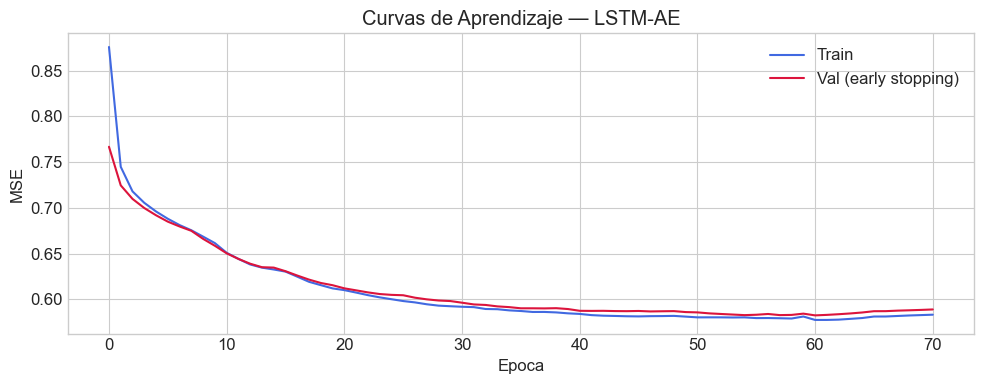

Mejor val_loss: 0.582394


In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'], 'royalblue', label='Train')
ax.plot(history.history['val_loss'], 'crimson', label='Val (early stopping)')
ax.set(xlabel='Epoca', ylabel='MSE', title='Curvas de Aprendizaje — LSTM-AE')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Mejor val_loss: {min(history.history["val_loss"]):.6f}')

## 6. Calibracion: MSE Ponderado + Umbral

Mismo approach que NB04 v3: MSE por feature ponderado por poder discriminante
(AUC-ROC individual en val). La ventaja del LSTM es que el error de reconstruccion
temporal amplifica la señal — una ventana con ataque sostenido genera error alto
en TODOS los timesteps, no solo en los features discriminantes.

In [9]:
def calibrate_threshold(y_true, scores, beta=1.0):
    precisions, recalls, thresholds = precision_recall_curve(y_true, scores)
    precisions = precisions[:-1]
    recalls    = recalls[:-1]
    fbeta = ((1 + beta**2) * precisions * recalls /
             (beta**2 * precisions + recalls + 1e-10))
    best_idx = np.argmax(fbeta)
    best_thr = thresholds[best_idx]
    n = len(thresholds)
    idx = np.linspace(0, n-1, min(500, n), dtype=int)
    results_df = pd.DataFrame({
        'threshold': thresholds[idx], 'precision': precisions[idx],
        'recall': recalls[idx],
        'f1': ((2*precisions*recalls)/(precisions+recalls+1e-10))[idx],
        'f2': ((5*precisions*recalls)/(4*precisions+recalls+1e-10))[idx],
    })
    return best_thr, fbeta[best_idx], results_df

# ── MSE por feature por ventana en val ──
val_recon = lstm_ae.predict(X_val_w, batch_size=BATCH_SIZE, verbose=0)
# Shape: (n_windows, 60, 14) → MSE per feature = mean over timesteps
mse_per_feature_val = np.mean((X_val_w - val_recon)**2, axis=1)  # (n_windows, 14)

# ── AUC-ROC individual por feature → pesos ──
print('Poder discriminante por feature (AUC-ROC en val):')
feature_aucs = []
for j, fname in enumerate(feat_names):
    try:
        auc_j = roc_auc_score(y_val_w, mse_per_feature_val[:, j])
    except ValueError:
        auc_j = 0.5
    feature_aucs.append(auc_j)
    marker = ' <<<' if auc_j > 0.60 else ''
    print(f'  {fname:30s}  AUC={auc_j:.4f}{marker}')

feature_aucs = np.array(feature_aucs)
weights = np.maximum(feature_aucs - 0.5, 0)
weights = weights / (weights.sum() + 1e-10)

print()
print('Pesos normalizados (features con peso > 0.01):')
for j, fname in enumerate(feat_names):
    if weights[j] > 0.01:
        print(f'  {fname:30s}  w={weights[j]:.4f}')

# ── Score ponderado ──
scores_val_w = np.sum(mse_per_feature_val * weights[None, :], axis=1)

# Test
test_recon = lstm_ae.predict(X_test_w, batch_size=BATCH_SIZE, verbose=0)
mse_per_feature_test = np.mean((X_test_w - test_recon)**2, axis=1)
scores_test_w = np.sum(mse_per_feature_test * weights[None, :], axis=1)

# Calibrar
best_thr, best_f1_val, cal_df = calibrate_threshold(y_val_w, scores_val_w, beta=1.0)
_, best_f2_val, _ = calibrate_threshold(y_val_w, scores_val_w, beta=2.0)

print()
print(f'Score: MSE ponderado (weighted by per-feature AUC)')
print(f'Umbral optimo (val, F1): {best_thr:.6f}')
print(f'  F1 en val: {best_f1_val:.4f}')
print(f'  F2 en val: {best_f2_val:.4f}')

Poder discriminante por feature (AUC-ROC en val):
  Global_active_power             AUC=0.7465 <<<
  Global_reactive_power           AUC=0.7793 <<<
  Voltage                         AUC=0.6849 <<<
  Global_intensity                AUC=0.6941 <<<
  Sub_metering_1                  AUC=0.7883 <<<
  Sub_metering_2                  AUC=0.6996 <<<
  Sub_metering_3                  AUC=0.6823 <<<
  VI_residual                     AUC=0.9143 <<<
  hour_sin                        AUC=0.7583 <<<
  hour_cos                        AUC=0.7127 <<<
  dow_sin                         AUC=0.7576 <<<
  dow_cos                         AUC=0.6846 <<<
  gap_diff1                       AUC=0.5134
  vi_res_abs                      AUC=0.8658 <<<

Pesos normalizados (features con peso > 0.01):
  Global_active_power             w=0.0751
  Global_reactive_power           w=0.0851
  Voltage                         w=0.0563
  Global_intensity                w=0.0591
  Sub_metering_1                  w=0.0878
  Sub

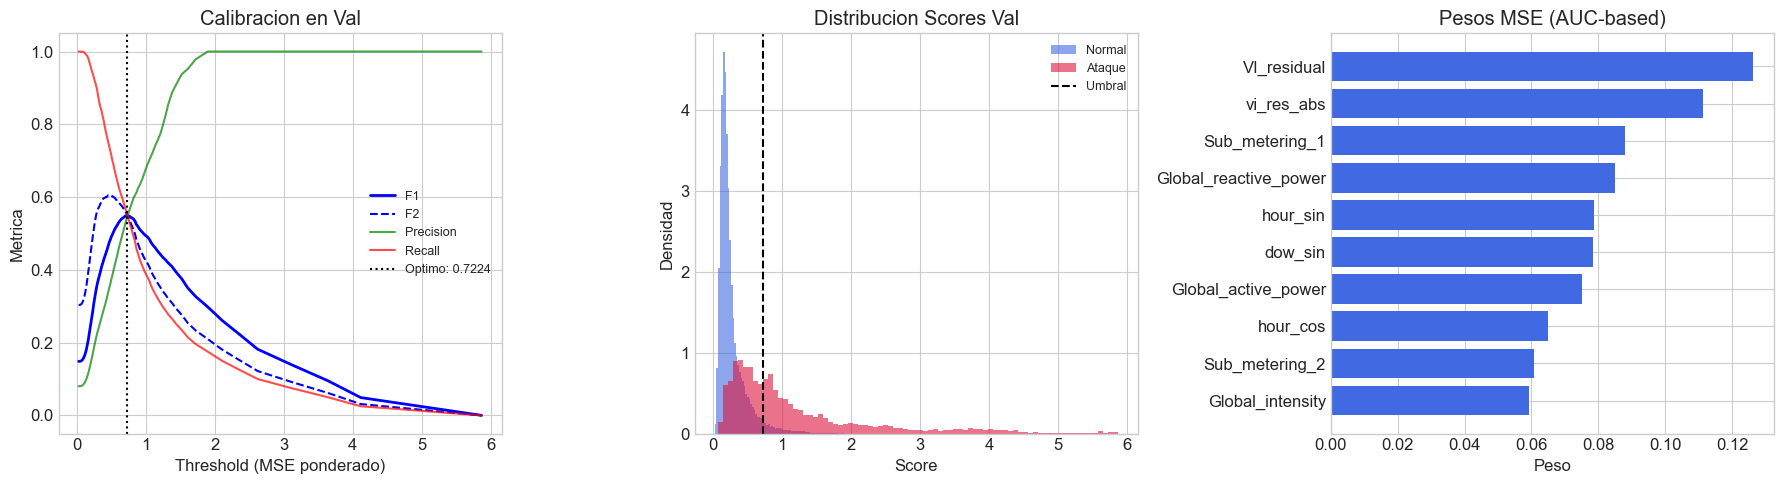

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(cal_df['threshold'], cal_df['f1'], 'b-', lw=2, label='F1')
ax.plot(cal_df['threshold'], cal_df['f2'], 'b--', lw=1.5, label='F2')
ax.plot(cal_df['threshold'], cal_df['precision'], 'g-', lw=1.5, label='Precision', alpha=0.7)
ax.plot(cal_df['threshold'], cal_df['recall'], 'r-', lw=1.5, label='Recall', alpha=0.7)
ax.axvline(best_thr, color='k', linestyle=':', lw=1.5, label=f'Optimo: {best_thr:.4f}')
ax.set(xlabel='Threshold (MSE ponderado)', ylabel='Metrica', title='Calibracion en Val')
ax.legend(fontsize=9)

ax = axes[1]
ax.hist(scores_val_w[y_val_w == 0], bins=80, alpha=0.6, color='royalblue', label='Normal', density=True)
ax.hist(scores_val_w[y_val_w == 1], bins=80, alpha=0.6, color='crimson', label='Ataque', density=True)
ax.axvline(best_thr, color='k', linestyle='--', lw=1.5, label='Umbral')
ax.set(xlabel='Score', ylabel='Densidad', title='Distribucion Scores Val')
ax.legend(fontsize=9)

ax = axes[2]
sorted_idx = np.argsort(weights)[::-1]
top_n = min(10, (weights > 0.01).sum())
top_idx = sorted_idx[:top_n]
ax.barh([feat_names[j] for j in top_idx], weights[top_idx], color='royalblue')
ax.set_xlabel('Peso')
ax.set_title('Pesos MSE (AUC-based)')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 7. Evaluacion RAW (nivel ventana)

In [11]:
y_pred_w = (scores_test_w > best_thr).astype(int)

print('=' * 60)
print('METRICAS — LSTM-AE (nivel ventana 60 min)')
print('=' * 60)
print()
print(classification_report(y_test_w, y_pred_w, target_names=['Normal', 'Ataque']))

f1   = f1_score(y_test_w, y_pred_w)
f2   = fbeta_score(y_test_w, y_pred_w, beta=2)
prec = precision_score(y_test_w, y_pred_w)
rec  = recall_score(y_test_w, y_pred_w)
auc_roc = roc_auc_score(y_test_w, scores_test_w)
auc_pr  = average_precision_score(y_test_w, scores_test_w)

print(f'AUC-ROC: {auc_roc:.4f}  |  AUC-PR: {auc_pr:.4f}')
print(f'F1: {f1:.4f}  |  F2: {f2:.4f}  |  Precision: {prec:.4f}  |  Recall: {rec:.4f}')

METRICAS — LSTM-AE (nivel ventana 60 min)

              precision    recall  f1-score   support

      Normal       0.97      0.95      0.96    553350
      Ataque       0.56      0.64      0.59     51590

    accuracy                           0.93    604940
   macro avg       0.76      0.79      0.78    604940
weighted avg       0.93      0.93      0.93    604940

AUC-ROC: 0.9146  |  AUC-PR: 0.6313
F1: 0.5927  |  F2: 0.6176  |  Precision: 0.5554  |  Recall: 0.6354


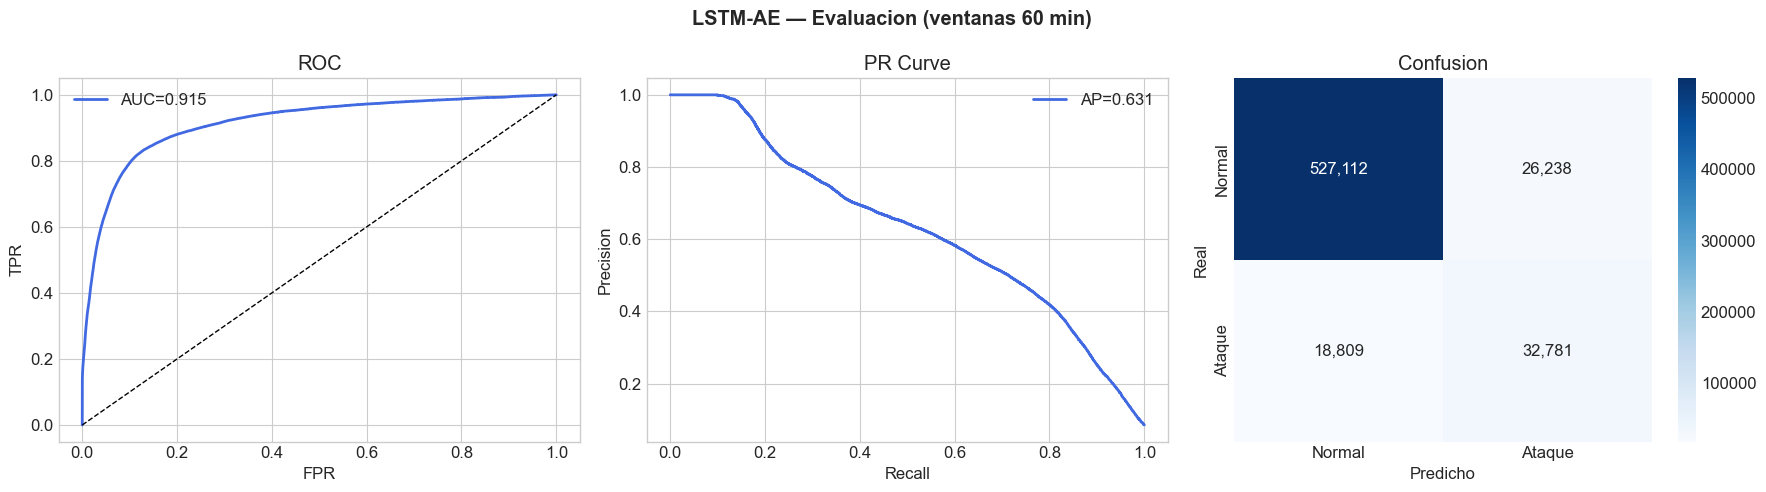

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fpr, tpr, _ = roc_curve(y_test_w, scores_test_w)
axes[0].plot(fpr, tpr, 'royalblue', lw=2, label=f'AUC={auc_roc:.3f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC')
axes[0].legend()

pr_c, rc_c, _ = precision_recall_curve(y_test_w, scores_test_w)
axes[1].plot(rc_c, pr_c, 'royalblue', lw=2, label=f'AP={auc_pr:.3f}')
axes[1].set(xlabel='Recall', ylabel='Precision', title='PR Curve')
axes[1].legend()

cm = confusion_matrix(y_test_w, y_pred_w)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[2],
            xticklabels=['Normal','Ataque'], yticklabels=['Normal','Ataque'])
axes[2].set(xlabel='Predicho', ylabel='Real', title='Confusion')
plt.suptitle('LSTM-AE — Evaluacion (ventanas 60 min)', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Expansion a Timesteps + Temporal Voting

Expandir predicciones de ventana a nivel de minuto, luego aplicar temporal voting.

In [13]:
# ── Expandir ventana → timestep ──
n_test = len(X_test_scaled)
scores_per_ts = np.full(n_test, -np.inf)
preds_per_ts  = np.zeros(n_test, dtype=int)

for i, s in enumerate(test_starts):
    e = min(s + WINDOW_SIZE, n_test)
    scores_per_ts[s:e] = np.maximum(scores_per_ts[s:e], scores_test_w[i])
    if y_pred_w[i] == 1:
        preds_per_ts[s:e] = 1

scores_per_ts[scores_per_ts == -np.inf] = 0.0

# ── Temporal Voting sobre predicciones expandidas ──
def temporal_vote_vectorized(y_pred, W, K):
    cum = np.concatenate([[0], np.cumsum(y_pred)])
    n = len(y_pred)
    ends = np.arange(1, n + 1)
    starts_v = np.maximum(0, ends - W)
    votes = cum[ends] - cum[starts_v]
    return (votes >= K).astype(int)

# Grid search (W, K) en val expandido
n_val = len(X_val_scaled)
scores_val_ts = np.full(n_val, -np.inf)
preds_val_ts  = np.zeros(n_val, dtype=int)
y_pred_val_w  = (scores_val_w > best_thr).astype(int)

for i, s in enumerate(val_starts):
    e = min(s + WINDOW_SIZE, n_val)
    scores_val_ts[s:e] = np.maximum(scores_val_ts[s:e], scores_val_w[i])
    if y_pred_val_w[i] == 1:
        preds_val_ts[s:e] = 1

W_candidates = [3, 5, 7, 9, 11, 15, 21]
best_wk_f1, best_W, best_K = 0, 3, 2
grid_results = []

for W in W_candidates:
    for K in range(2, W + 1):
        y_sm = temporal_vote_vectorized(preds_val_ts, W, K)
        f1_sm = f1_score(y_val, y_sm)
        pr_sm = precision_score(y_val, y_sm, zero_division=0)
        rc_sm = recall_score(y_val, y_sm)
        grid_results.append({'W': W, 'K': K, 'f1': f1_sm,
                             'precision': pr_sm, 'recall': rc_sm})
        if f1_sm > best_wk_f1:
            best_wk_f1, best_W, best_K = f1_sm, W, K

grid_df = pd.DataFrame(grid_results)
best_row = grid_df.loc[grid_df['f1'].idxmax()]
print(f'Mejor (W,K): W={best_W}, K={best_K}')
print(f'  F1={best_row["f1"]:.4f}  P={best_row["precision"]:.4f}  R={best_row["recall"]:.4f}')

# Aplicar al test
y_pred_smooth = temporal_vote_vectorized(preds_per_ts, best_W, best_K)

f1_s   = f1_score(y_test, y_pred_smooth)
f2_s   = fbeta_score(y_test, y_pred_smooth, beta=2)
prec_s = precision_score(y_test, y_pred_smooth)
rec_s  = recall_score(y_test, y_pred_smooth)

print()
print('=' * 70)
print('COMPARACION — LSTM-AE: RAW (timestep) vs TEMPORAL VOTING')
print('=' * 70)
raw_f1_ts  = f1_score(y_test, preds_per_ts)
raw_pr_ts  = precision_score(y_test, preds_per_ts)
raw_rc_ts  = recall_score(y_test, preds_per_ts)
raw_f2_ts  = fbeta_score(y_test, preds_per_ts, beta=2)
print()
print(f'  {"Metrica":12s} {"Raw":>10s} {"Smoothed":>10s} {"Delta":>10s}')
print('  ' + '-' * 45)
for name, raw_v, sm_v in [
    ('F1',        raw_f1_ts, f1_s),
    ('F2',        raw_f2_ts, f2_s),
    ('Precision',  raw_pr_ts, prec_s),
    ('Recall',     raw_rc_ts, rec_s),
]:
    delta = sm_v - raw_v
    print(f'  {name:12s} {raw_v:>10.4f} {sm_v:>10.4f} {delta:>+10.4f}')
print()
print(f'  Filtro: W={best_W}, K={best_K}')
print()
print(classification_report(y_test, y_pred_smooth, target_names=['Normal', 'Ataque']))

Mejor (W,K): W=21, K=21
  F1=0.4124  P=0.2798  R=0.7841

COMPARACION — LSTM-AE: RAW (timestep) vs TEMPORAL VOTING

  Metrica             Raw   Smoothed      Delta
  ---------------------------------------------
  F1               0.3924     0.4159    +0.0235
  F2               0.5861     0.5939    +0.0078
  Precision        0.2531     0.2774    +0.0243
  Recall           0.8736     0.8310    -0.0426

  Filtro: W=21, K=21

              precision    recall  f1-score   support

      Normal       0.99      0.88      0.93    573727
      Ataque       0.28      0.83      0.42     31272

    accuracy                           0.88    604999
   macro avg       0.63      0.86      0.67    604999
weighted avg       0.95      0.88      0.91    604999



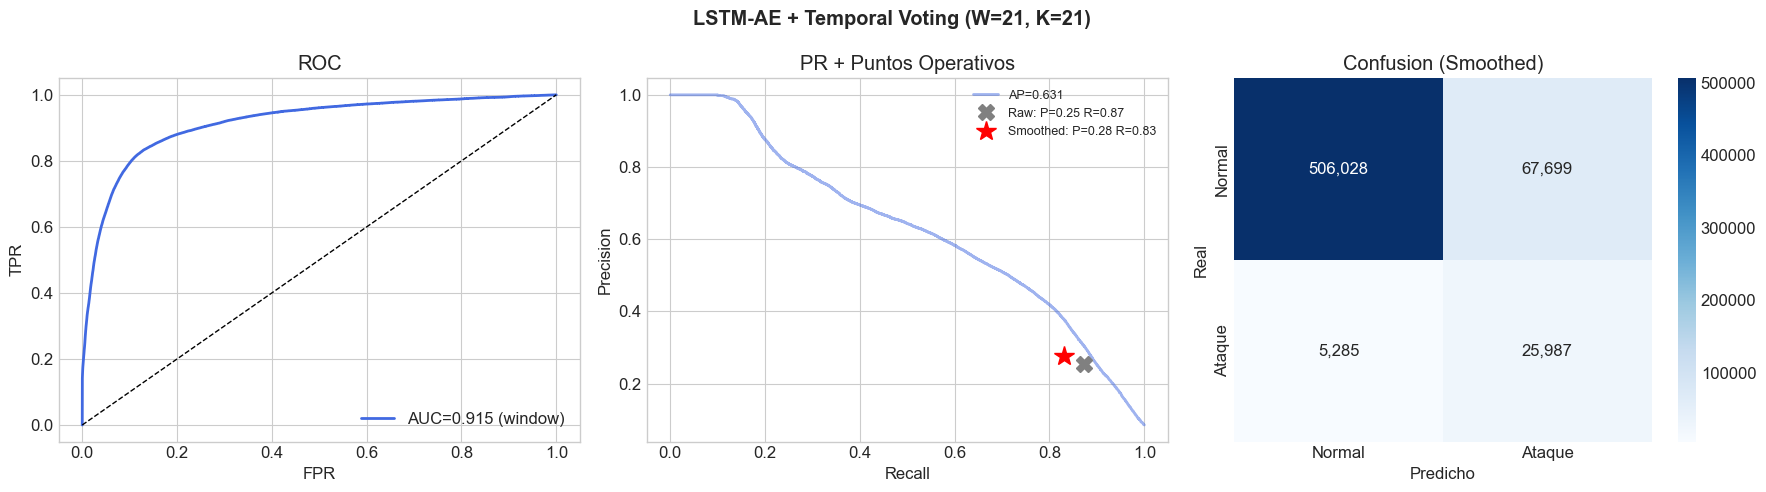

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(fpr, tpr, 'royalblue', lw=2, label=f'AUC={auc_roc:.3f} (window)')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC')
axes[0].legend()

axes[1].plot(rc_c, pr_c, 'royalblue', lw=2, label=f'AP={auc_pr:.3f}', alpha=0.5)
axes[1].plot(raw_rc_ts, raw_pr_ts, 'X', color='gray', markersize=12,
             label=f'Raw: P={raw_pr_ts:.2f} R={raw_rc_ts:.2f}')
axes[1].plot(rec_s, prec_s, '*', color='red', markersize=15,
             label=f'Smoothed: P={prec_s:.2f} R={rec_s:.2f}')
axes[1].set(xlabel='Recall', ylabel='Precision', title='PR + Puntos Operativos')
axes[1].legend(fontsize=9)

cm_s = confusion_matrix(y_test, y_pred_smooth)
sns.heatmap(cm_s, annot=True, fmt=',d', cmap='Blues', ax=axes[2],
            xticklabels=['Normal','Ataque'], yticklabels=['Normal','Ataque'])
axes[2].set(xlabel='Predicho', ylabel='Real', title='Confusion (Smoothed)')
plt.suptitle(f'LSTM-AE + Temporal Voting (W={best_W}, K={best_K})', fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Recall por Tipo x Severidad (Smoothed)

Recall por tipo x severidad:
  Tipo                     N      Low      Med     High    Total
  -------------------------------------------------------
  scaling              4,146    0.741    0.800    0.917    0.812
  offset               4,441    0.666    0.789    0.975    0.827
  noise                4,579    1.000    1.000    1.000    1.000
  ramp                 4,565    0.465    0.607    0.834    0.614
  step                 5,014    0.718    0.782    0.751    0.752
  replay               4,279    0.804    0.942    0.905    0.888
  voltage_spoof        4,248    0.814    1.000    1.000    0.941


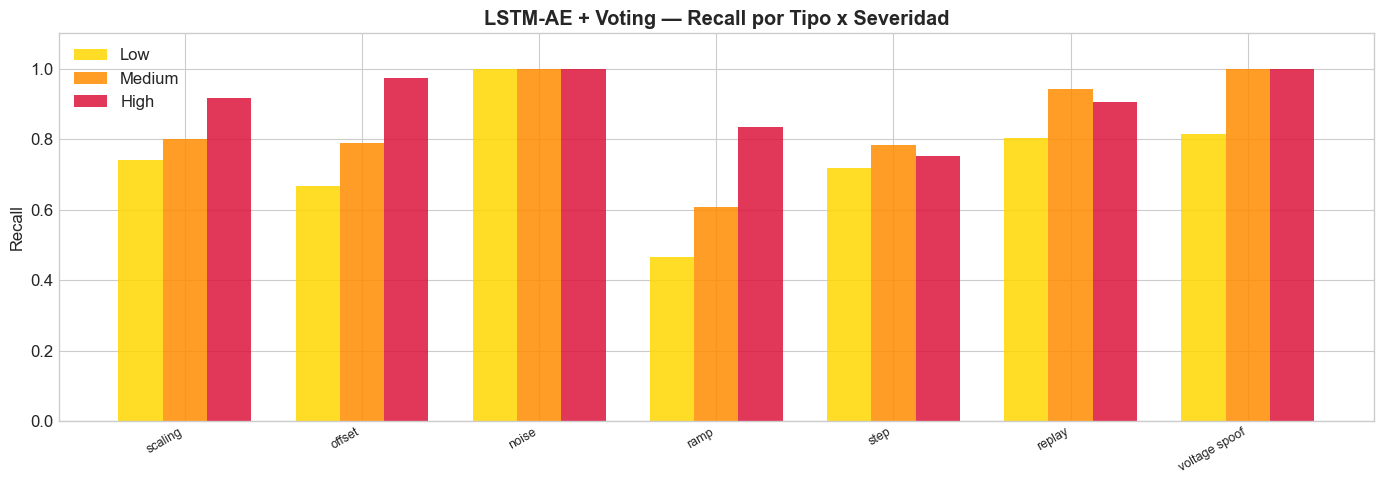

In [15]:
def recall_by_type_severity(attack_types_col, severity_col, y_true, y_pred,
                            attack_types_list, title_prefix):
    print(f'Recall por tipo x severidad:')
    print(f'  {"Tipo":18s} {"N":>7s} {"Low":>8s} {"Med":>8s} {"High":>8s} {"Total":>8s}')
    print('  ' + '-' * 55)
    recall_data = {}
    for t in attack_types_list:
        mask_t = (attack_types_col == t)
        n_t = (mask_t & (y_true == 1)).sum()
        row = f'  {t:18s} {n_t:>7,}'
        for sev in ['low', 'medium', 'high']:
            mask = mask_t & (severity_col == sev) & (y_true == 1)
            n = mask.sum()
            if n > 0:
                r = (y_pred[mask] == 1).sum() / n
                row += f' {r:>8.3f}'
            else:
                r = np.nan
                row += f' {"--":>8s}'
            recall_data[(t, sev)] = r
        mask_all = mask_t & (y_true == 1)
        n_all = mask_all.sum()
        r_t = (y_pred[mask_all] == 1).sum() / n_all if n_all > 0 else 0
        row += f' {r_t:>8.3f}'
        print(row)

    fig, ax = plt.subplots(figsize=(14, 5))
    x = np.arange(len(attack_types_list))
    w = 0.25
    sev_colors = {'low': '#FFD700', 'medium': '#FF8C00', 'high': '#DC143C'}
    for i, (sev, c) in enumerate(sev_colors.items()):
        vals = [recall_data.get((t, sev), 0) for t in attack_types_list]
        vals = [v if not (isinstance(v, float) and np.isnan(v)) else 0 for v in vals]
        ax.bar(x + i * w, vals, w, label=sev.capitalize(), color=c, alpha=0.85)
    ax.set_xticks(x + w)
    ax.set_xticklabels([t.replace('_', ' ') for t in attack_types_list],
                        rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Recall'); ax.set_ylim(0, 1.1)
    ax.set_title(f'{title_prefix} — Recall por Tipo x Severidad', fontweight='bold')
    ax.legend()
    plt.tight_layout(); plt.show()
    return recall_data

recall_data = recall_by_type_severity(
    df_test['attack_type'].values, df_test['severity'].values,
    y_test, y_pred_smooth, ATTACK_TYPES, 'LSTM-AE + Voting')

## 10. Latencia de Deteccion (Smoothed)

In [16]:
def compute_detection_latency(df_preds, score_col, threshold):
    results = []
    attacked = df_preds[df_preds['episode_id'] >= 0]
    for ep_id, group in attacked.groupby('episode_id'):
        group = group.sort_index()
        detections = group[group[score_col] > threshold]
        ep_start = group.index[0]
        results.append({
            'episode_id': ep_id, 'type': group['attack_type'].iloc[0],
            'severity': group['severity'].iloc[0], 'duration_min': len(group),
            'latency_min': ((detections.index[0] - ep_start).total_seconds() / 60
                            if len(detections) > 0 else np.nan),
            'detected': len(detections) > 0
        })
    return pd.DataFrame(results)

def print_latency_summary(lat_df):
    det_rate = lat_df['detected'].mean()
    detected = lat_df[lat_df['detected']]
    med_lat  = detected['latency_min'].median() if len(detected) > 0 else np.nan
    print(f'Deteccion por episodio: {det_rate:.1%} ({lat_df["detected"].sum()}/{len(lat_df)})')
    if not np.isnan(med_lat):
        print(f'Latencia mediana:       {med_lat:.1f} min')
    print()
    for sev in ['low', 'medium', 'high']:
        sub = lat_df[lat_df['severity'] == sev]
        if len(sub) == 0: continue
        det = sub['detected'].mean()
        det_sub = sub[sub['detected']]
        lat = det_sub['latency_min'].median() if len(det_sub) > 0 else np.nan
        lat_s = f'{lat:.1f} min' if not np.isnan(lat) else 'N/A'
        print(f'  {sev:8s}: deteccion {det:.0%}  |  latencia mediana {lat_s}')
    return det_rate, med_lat

df_test_scored = df_test.copy()
df_test_scored['lstm_pred_smooth'] = y_pred_smooth.astype(float)
lat_df = compute_detection_latency(df_test_scored, 'lstm_pred_smooth', 0.5)
det_rate, med_lat = print_latency_summary(lat_df)

Deteccion por episodio: 92.6% (324/350)
Latencia mediana:       0.0 min

  low     : deteccion 85%  |  latencia mediana 0.0 min
  medium  : deteccion 95%  |  latencia mediana 0.0 min
  high    : deteccion 97%  |  latencia mediana 0.0 min


## 11. Edge Computing + Guardado

In [17]:
model_path = os.path.join(DATA_DIR, 'model_lstm_autoencoder.keras')
try:
    lstm_ae.save(model_path)
except Exception:
    model_path = os.path.join(DATA_DIR, 'model_lstm_autoencoder.h5')
    lstm_ae.save(model_path)
size_kb = os.path.getsize(model_path) / 1e3

joblib.dump(scaler, os.path.join(DATA_DIR, 'scaler_lstm_autoencoder.pkl'))
np.save(os.path.join(DATA_DIR, 'feature_weights_lstm_ae.npy'), weights)

_ = lstm_ae.predict(X_test_w[:10], batch_size=BATCH_SIZE, verbose=0)
times = []
for _ in range(5):
    t0 = time.time()
    lstm_ae.predict(X_test_w[:1000], batch_size=BATCH_SIZE, verbose=0)
    times.append(time.time() - t0)
ms_win_avg = np.mean(times) / 1000 * 1000
ms_smp_avg = ms_win_avg / WINDOW_SIZE

print('=' * 55)
print('EDGE COMPUTING — LSTM-AE + TEMPORAL VOTING')
print('=' * 55)
print(f'  Parametros:       {lstm_ae.count_params():,}')
print(f'  Scoring:          MSE ponderado ({(weights>0.01).sum()} features activas)')
print(f'  Filtro:           W={best_W}, K={best_K}')
print(f'  Tamano en disco:  {size_kb:.1f} KB')
print(f'  Latencia ventana: {ms_win_avg:.2f} ms (60 min de datos)')
print(f'  Latencia equiv:   {ms_smp_avg:.4f} ms/muestra')
print(f'  Entrenamiento:    {t_train:.1f} s ({t_train/60:.1f} min)')

df_out = df_test.copy()
df_out['lstm_score'] = scores_per_ts
df_out['lstm_pred_raw']    = preds_per_ts
df_out['lstm_pred_smooth'] = y_pred_smooth
df_out.to_csv(os.path.join(DATA_DIR, 'predictions_lstm_autoencoder.csv'))
np.save(os.path.join(DATA_DIR, 'threshold_lstm_ae.npy'), np.array([best_thr]))
lat_df.to_csv(os.path.join(DATA_DIR, 'latency_lstm_autoencoder.csv'), index=False)

metrics = {
    'model': 'LSTM-Autoencoder + Temporal Voting',
    'feature_mode': 'medium + vi_res_abs',
    'scoring': 'weighted_mse',
    'raw_f1': round(raw_f1_ts, 4), 'raw_f2': round(raw_f2_ts, 4),
    'raw_precision': round(raw_pr_ts, 4), 'raw_recall': round(raw_rc_ts, 4),
    'f1': round(f1_s, 4), 'f2': round(f2_s, 4),
    'precision': round(prec_s, 4), 'recall': round(rec_s, 4),
    'auc_roc': round(auc_roc, 4), 'auc_pr': round(auc_pr, 4),
    'threshold': round(float(best_thr), 8),
    'temporal_W': best_W, 'temporal_K': best_K,
    'model_size_kb': round(size_kb, 1),
    'ms_per_window': round(ms_win_avg, 4), 'ms_per_sample': round(ms_smp_avg, 4),
    'n_params': lstm_ae.count_params(), 'n_features': n_features, 'bottleneck': 16,
    'window_size': WINDOW_SIZE, 'train_step': TRAIN_STEP,
    'train_time_s': round(t_train, 1),
    'detection_rate': round(det_rate, 4),
    'median_latency_min': round(float(med_lat), 1) if not np.isnan(med_lat) else None,
    'granularity': f'{WINDOW_SIZE} min window, 1 min output',
    'feature_names': feat_names,
    'feature_weights': {fn: round(float(w), 4) for fn, w in zip(feat_names, weights) if w > 0.01},
}
with open(os.path.join(DATA_DIR, 'metrics_lstm_autoencoder.json'), 'w') as f:
    json.dump(metrics, f, indent=2)

print()
print('Guardado en data/:')
for fn in ['predictions_lstm_autoencoder.csv', 'metrics_lstm_autoencoder.json',
           'model_lstm_autoencoder.keras', 'scaler_lstm_autoencoder.pkl',
           'feature_weights_lstm_ae.npy', 'threshold_lstm_ae.npy',
           'latency_lstm_autoencoder.csv']:
    print(f'  * {fn}')

EDGE COMPUTING — LSTM-AE + TEMPORAL VOTING
  Parametros:       56,286
  Scoring:          MSE ponderado (13 features activas)
  Filtro:           W=21, K=21
  Tamano en disco:  725.2 KB
  Latencia ventana: 0.24 ms (60 min de datos)
  Latencia equiv:   0.0041 ms/muestra
  Entrenamiento:    284.2 s (4.7 min)

Guardado en data/:
  * predictions_lstm_autoencoder.csv
  * metrics_lstm_autoencoder.json
  * model_lstm_autoencoder.keras
  * scaler_lstm_autoencoder.pkl
  * feature_weights_lstm_ae.npy
  * threshold_lstm_ae.npy
  * latency_lstm_autoencoder.csv


## 12. Resumen

### Ventajas del LSTM-AE sobre IF y Dense-AE

| Aspecto | IF | Dense-AE | LSTM-AE |
|---------|-----|----------|---------|
| Contexto temporal | Ninguno (punto a punto) | Ninguno | **60 min de secuencia** |
| Compresion | N/A | 14:3 = 4.7:1 | 840:16 = **52:1** |
| Señal temporal | No ve tendencias | No ve tendencias | Aprende patrones temporales normales |
| Scoring | Score IF | MSE ponderado | MSE ponderado + temporal |

### Por que deberia superar a los otros

El LSTM-AE tiene una ventaja fundamental: comprime 60 minutos × 14 features
en 16 valores. Si un episodio FDI de 90 min distorsiona 30 de esos 60 minutos
en la ventana, la representacion comprimida NO puede acomodarlo — generando
MSE alta en toda la reconstruccion, no solo en las features atacadas.

Los modelos punto-a-punto (IF, Dense-AE) ven cada minuto aislado. El LSTM
ve el contexto completo: un valor bajo sostenido durante 60 min a las 15h
es anomalo de una forma que minuto a minuto no se detecta.